**24BAD130 Vishal S ML Lab Exp -07**

**SCENARIO 1 – CLUSTERING USING K-MEANS**

Problem Statement
Group customers/data points into clusters based on similarity using K-Means clustering.

Dataset (Kaggle – Public)
Mall Customer Segmentation Dataset
Dataset Link: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python
(You can use any dataset with numerical features)

Target Variable: Cluster labels (no predefined labels – unsupervised learning)
Input Feature:
• Annual Income
• Spending Score
• Age (optional)

IN-LAB TASKS
1.	Import required Python libraries (NumPy, Pandas, Matplotlib, Scikit-learn)
2.	Load the dataset
3.	Perform data preprocessing (handling missing values, scaling)
4.	Select relevant features
5.	Use Elbow Method to determine optimal K
6.	Apply K-Means clustering
7.	Assign cluster labels
8.	Visualize clusters
9.	Interpret cluster characteristics

Evaluation Metrics
• Inertia (Within-cluster sum of squares)
• Silhouette Score

Analysis Tasks
• Observe how different K values affect clustering
• Analyze compactness and separation of clusters
• Identify customer segments (e.g., high income–high spending)
• Study sensitivity to initialization




Visualization
• Elbow curve (K vs inertia)
• Scatter plot of clusters
• Cluster centroids


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
#2.Load dataset
data = pd.read_csv("Mall_Customers.csv")

In [3]:
# Display first 5 rows
print(data.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [4]:
# 3. Data preprocessing
# Check missing values
print(data.isnull().sum())
# Drop missing values if any
data = data.dropna()



CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [5]:
# Select relevant features
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]
# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

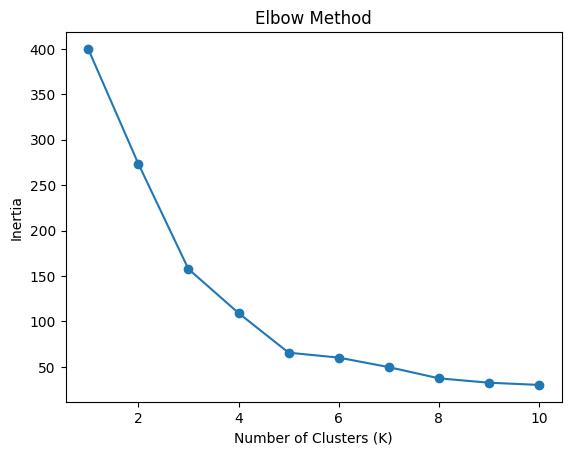

In [6]:
# 5. Elbow Method to find optimal K
inertia = []

K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

In [ ]:
# 6. Apply K-Means clustering
# Choose optimal K (5)
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
# 7. Assign cluster labels
# Add cluster labels to dataset
data['Cluster'] = clusters

print(data.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


In [8]:
# Inertia
print("Inertia:", kmeans.inertia_)

# Silhouette Score
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

Inertia: 65.5684081557168
Silhouette Score: 0.5546571631111091


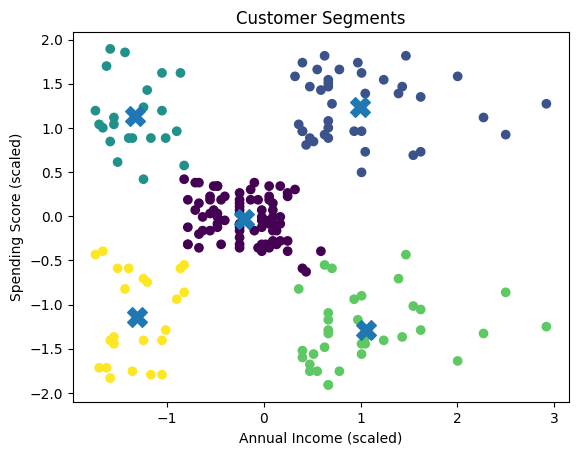

In [9]:

# 8. Visualize clusters
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)

# Plot centroids
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, marker='X')

plt.title("Customer Segments")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.show()

**SCENARIO 2 – CLUSTERING USING GMM**

Problem Statement
Cluster data using Gaussian Mixture Models to capture probabilistic cluster membership.

Dataset (Same / Alternative Dataset)
Same dataset (or any numerical dataset)

Target Variable: Cluster probabilities and labels
Input Features
• Annual Income
• Spending Score
• Age (optional)

IN-LAB TASKS
1.	Load dataset
2.	Perform preprocessing and scaling
3.	Apply Gaussian Mixture Model (GMM)
4.	Choose number of components (clusters)
5.	Fit model using Expectation-Maximization (EM)
6.	Predict cluster probabilities
7.	Assign clusters based on highest probability
8.	Compare with K-Means clustering

Evaluation Metrics
• Log-Likelihood
• AIC (Akaike Information Criterion)
• BIC (Bayesian Information Criterion)
• Silhouette Score

Analysis Tasks
• Compare soft vs hard clustering
• Analyze overlapping clusters
• Observe cluster shapes (elliptical vs spherical)
• Compare flexibility with K-Means

Visualization
• Cluster probability distribution
• GMM contour plots
• Comparison plot (K-Means vs GMM)


In [11]:
# 1. Load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

In [12]:
#2. Load dataset
data = pd.read_csv("Mall_Customers.csv")
print(data.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [13]:
# Remove missing values
data = data.dropna()
# Select features
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled.shape)

(200, 2)


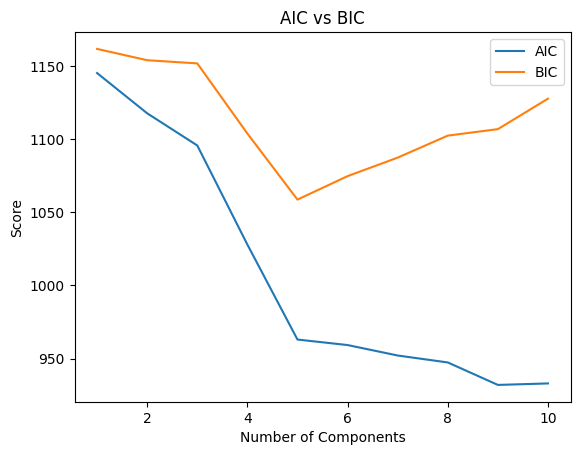

In [14]:
n_components = range(1, 11)
aic = []
bic = []

for n in n_components:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X_scaled)
    aic.append(gmm.aic(X_scaled))
    bic.append(gmm.bic(X_scaled))

# Plot AIC & BIC
plt.plot(n_components, aic, label='AIC')
plt.plot(n_components, bic, label='BIC')
plt.xlabel("Number of Components")
plt.ylabel("Score")
plt.legend()
plt.title("AIC vs BIC")
plt.show()

In [ ]:
# Choose optimal components 
gmm = GaussianMixture(n_components=5, random_state=42)

gmm.fit(X_scaled)

,n_components,5
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,42


In [16]:
probabilities = gmm.predict_proba(X_scaled)
# Assign cluster labels
data['GMM_Cluster'] = np.argmax(probabilities, axis=1)


In [17]:
print(data[['GMM_Cluster']].head())
print(probabilities[:5])  # first 5 probability rows

   GMM_Cluster
0            4
1            2
2            4
3            2
4            4
[[1.57689698e-05 1.88009163e-08 9.52031247e-04 5.20013085e-08
  9.99032129e-01]
 [1.62776204e-05 1.89596786e-04 9.99790184e-01 4.21013390e-23
  3.94154449e-06]
 [2.21339374e-19 9.52615737e-19 1.22549539e-12 1.86223280e-04
  9.99813777e-01]
 [1.05444778e-04 1.80087695e-04 9.99693745e-01 3.79390067e-21
  2.07229768e-05]
 [6.47301428e-05 3.84273231e-08 1.55669540e-03 4.75722704e-08
  9.98378488e-01]]


In [18]:
clusters = gmm.predict(X_scaled)
data['GMM_Cluster'] = clusters
print(data.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   GMM_Cluster  
0            4  
1            2  
2            4  
3            2  
4            4  


In [19]:
# Log Likelihood
print("Log-Likelihood:", gmm.score(X_scaled))

# AIC & BIC
print("AIC:", gmm.aic(X_scaled))
print("BIC:", gmm.bic(X_scaled))

# Silhouette Score
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

Log-Likelihood: -2.262502621973241
AIC: 963.0010487892964
BIC: 1058.6522524191894
Silhouette Score: 0.5536892843811245


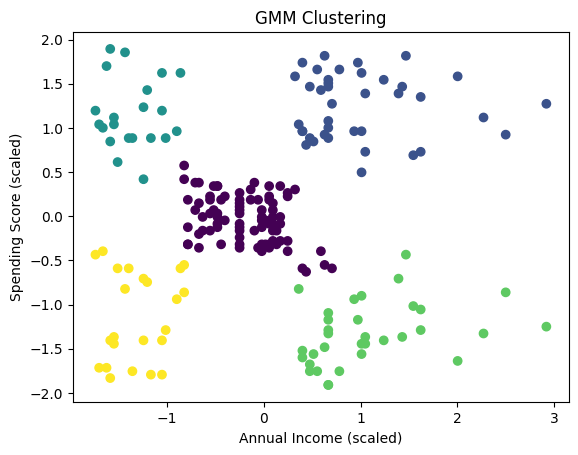

In [20]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.title("GMM Clustering")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.show()

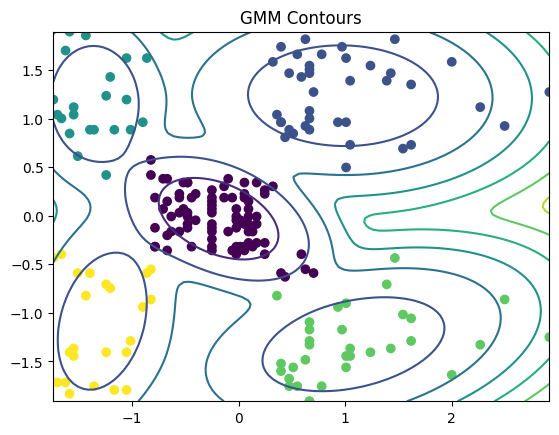

In [21]:
import numpy as np

x = np.linspace(X_scaled[:, 0].min(), X_scaled[:, 0].max(), 100)
y = np.linspace(X_scaled[:, 1].min(), X_scaled[:, 1].max(), 100)

X_grid, Y_grid = np.meshgrid(x, y)
grid = np.array([X_grid.ravel(), Y_grid.ravel()]).T

Z = -gmm.score_samples(grid)
Z = Z.reshape(X_grid.shape)

plt.contour(X_grid, Y_grid, Z)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.title("GMM Contours")
plt.show()

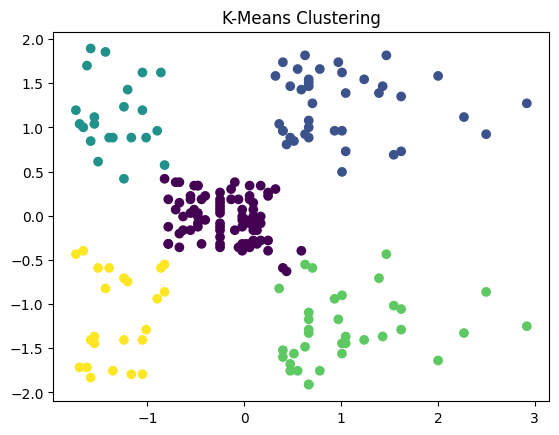

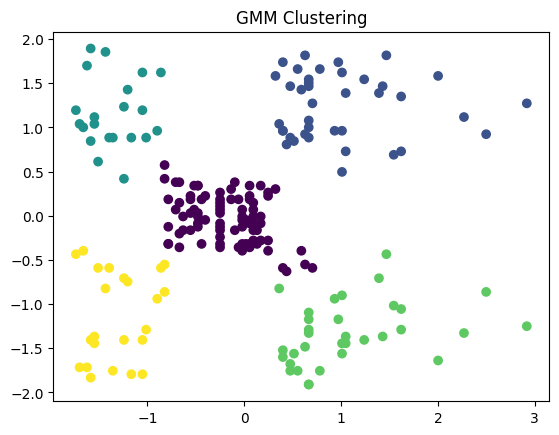

In [22]:
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels)
plt.title("K-Means Clustering")
plt.show()

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.title("GMM Clustering")
plt.show()